# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
!pip install imbalanced-learn

### 0.b Import Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "5"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [8]:
experiment_hypothesis = """
Logistic Regression with SMOTE oversampling should approach the performance
of the best tree-based models while addressing the root cause of Scurvy and
Night_Blindness underperformance.

All previous experiments used class weighting or scale_pos_weight to handle
the 12.5x imbalance. These approaches adjust the loss function but don't
change the fundamental data distribution — the model still sees only 95 Scurvy
and 134 Night_Blindness training samples. SMOTE addresses this directly by
synthetically generating new minority class samples, giving the model more
examples to learn reliable boundaries from.

Logistic Regression tests whether the 5 classes are linearly separable in
the current feature space. If the engineered features have created clean enough
boundaries, a linear model should perform competitively with the complex
tree-based models. It also provides a different perspective — the model's
coefficients show which features push predictions toward each class, which
is valuable for clinical interpretation alongside the tree-based rules from
Experiment 1.
"""

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [10]:
experiment_expectations = """
Target: macro F1 above 0.78 on the validation set, with Scurvy recall above
0.60 — the first time SMOTE is used, this should directly address the recall
problem that has persisted across all previous experiments.

Three ways this could go:

1. It works well (macro F1 above 0.82): SMOTE gives the model enough synthetic
   Scurvy and Night_Blindness samples to learn reliable boundaries. Scurvy
   recall crosses 0.60 and macro F1 matches or beats HistGradientBoosting.

2. It works partially (macro F1 between 0.72 and 0.82): SMOTE improves
   minority class recall but Logistic Regression cannot capture the non-linear
   boundaries that tree-based models exploit. Scurvy recall improves but
   macro F1 falls short of the tree-based models.

3. It doesn't improve enough (macro F1 below 0.72): The classes are not
   linearly separable and SMOTE synthetic samples introduce noise rather
   than useful signal. This would point to SVM with an RBF kernel as the
   better approach for non-linear boundaries in Experiment 6.
"""

In [11]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [12]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [13]:
# Shape confirmation
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution before SMOTE
print("\nClass distribution (train) before SMOTE:")
print(y_train['disease_diagnosis'].value_counts())

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train) before SMOTE:
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64


---
## D. Feature Selection


In [14]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Raw intake
    'vitamin_a_intake', 'vitamin_c_intake',
    'iron_intake', 'folate_intake', 'vitamin_b12_intake',

    # Symptom scores
    'rickets_symptom_score', 'anemia_symptom_score',

    # Engineered interaction features
    'vitamin_d_calcium_product', 'vegan_b12_risk',

    # Previous engineered features
    'vitamin_a_night_risk', 'scurvy_risk_index',

    # New features for Experiment 5
    'vitamin_d_ratio', 'vitamin_a_ratio', 'scurvy_linear_score',

    # Lifestyle
    'sun_exposure_type',

    # General severity
    'symptoms_count'
]

In [15]:
feature_selection_explanations = """
19 features are selected for this experiment, the largest feature set across
all experiments.

The core features from previous experiments are retained — vitamin_a_intake,
vitamin_c_intake and serum_vitamin_d have ranked in the top 3 consistently
and are non-negotiable. sun_exposure_type emerged as a strong contributor in
Experiments 3 and 4 and stays in.

rickets_symptom_score and anemia_symptom_score are added back. They were
dropped in Experiment 2 when the focus was on reducing redundancy, but for
Logistic Regression these scores provide direct linear signals for their
respective diseases. A logistic regression coefficient on rickets_symptom_score
directly captures how much bone pain and muscle weakness together push a
prediction toward Rickets.

iron_intake, folate_intake and vitamin_b12_intake remain from Experiment 3
where they all contributed positively. These raw intake columns give the model
direct nutritional signals beyond what the serum levels and engineered features
capture.

Three new ratio and linear features are added specifically for this experiment.
Logistic Regression works best with features that have linear relationships
with the outcome. Ratio features like vitamin_d_ratio and vitamin_a_ratio
capture the gap between what a patient consumes and what shows up in their
blood — a clinically meaningful signal that raw intake and serum values alone
cannot express individually. scurvy_linear_score creates a direct linear
separation signal for Scurvy by combining vitamin C intake and symptom burden
into a single value the model can use with a single coefficient.

SMOTE oversampling applied in section E will address the class imbalance
directly, giving the model synthetic Scurvy and Night_Blindness samples to
learn from rather than relying on class weighting alone.
"""

In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>


In [17]:
# From Experiment 2
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']

# From Experiment 4
for df in [X_train, X_val, X_test]:
    df['scurvy_risk_index'] = (
        df['vitamin_c_intake'] +
        df['has_bleeding_gums'] +
        df['has_fatigue']
    )

# Experiment 5 new features
for df in [X_train, X_val, X_test]:
    df['vitamin_d_ratio'] = df['serum_vitamin_d'] / (df['vitamin_d_intake'] + 1e-6)
    df['vitamin_a_ratio'] = df['vitamin_a_intake'] / (df['serum_folate'] + 1e-6)
    df['scurvy_linear_score'] = df['vitamin_c_intake'] - df['scurvy_symptom_score']

In [18]:
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 19)
X_val_model shape:   (690, 19)
X_test_model shape:  (691, 19)


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_model, y_train.values.ravel())

print("Class distribution after SMOTE:")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt}")
print(f"\nX_train_resampled shape: {X_train_resampled.shape}")

Class distribution after SMOTE:
  Anemia: 1182
  Healthy: 1182
  Night_Blindness: 1182
  Rickets_Osteomalacia: 1182
  Scurvy: 1182

X_train_resampled shape: (5910, 19)


In [20]:
data_transformation_1_explanations = """
SMOTE (Synthetic Minority Oversampling Technique) is applied to the training
set only — never to the validation or test sets.

SMOTE generates synthetic samples for minority classes by interpolating between
existing samples and their nearest neighbours in feature space. For each minority
class sample, it finds its k nearest neighbours and creates new synthetic points
along the line segments connecting them. This is fundamentally different from
simple duplication — the synthetic samples are new points in feature space that
the model hasn't seen before.

SMOTE is applied here because all previous experiments hit a ceiling on Scurvy
and Night_Blindness recall. class_weight and scale_pos_weight adjust the loss
function but the model still only learns from 95 Scurvy and 134 Night_Blindness
samples. SMOTE gives the model more boundary examples to learn from.

Critically, SMOTE is only applied to X_train_resampled - X_val_model and
X_test_model remain untouched. Applying SMOTE to validation or test sets would
give an artificially inflated view of performance that wouldn't reflect real
world data.
"""

In [21]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "vitamin_d_ratio"



In [22]:
for df in [X_train, X_val, X_test]:
    df['vitamin_d_ratio'] = df['serum_vitamin_d'] / (df['vitamin_d_intake'] + 1e-6)

In [23]:
feature_engineering_1_explanations = """
vitamin_d_ratio is the ratio of serum_vitamin_d to vitamin_d_intake.

A patient with low serum vitamin D despite adequate intake suggests an
absorption problem, their body is not processing the vitamin D they consume.
This is a different clinical presentation to someone with low intake causing
low serum levels. The ratio captures this gap in a single linear value that
Logistic Regression can use directly with a single coefficient.
"""

In [24]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "vitamin_a_ratio"



In [25]:
for df in [X_train, X_val, X_test]:
    df['vitamin_a_ratio'] = df['vitamin_a_intake'] / (df['serum_folate'] + 1e-6)

In [26]:
feature_engineering_2_explanations = """
vitamin_a_ratio is vitamin_a_intake divided by serum_folate.

Vitamin A and folate deficiencies often co-occur in malnourished patients.
A high vitamin A intake relative to folate levels suggests an imbalanced
nutritional profile that may help separate Night_Blindness from Anemia -
two classes that share fatigue as a symptom but have different nutritional
root causes.
"""

In [27]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "scurvy_linear_score"



In [28]:
for df in [X_train, X_val, X_test]:
    df['scurvy_linear_score'] = df['vitamin_c_intake'] - df['scurvy_symptom_score']

In [29]:
feature_engineering_3_explanations = """
scurvy_linear_score subtracts scurvy_symptom_score from vitamin_c_intake.

A very negative value means the patient has both low vitamin C intake and
high Scurvy symptoms simultaneously the clearest possible Scurvy signal.
A positive value means adequate vitamin C with no symptoms clearly not
Scurvy. This creates a direct linear separation that Logistic Regression
can exploit with a single negative coefficient for Scurvy prediction.
"""

In [30]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

In [32]:
algorithm_selection_explanations = """
Logistic Regression with SMOTE is chosen as Experiment 5 to test a completely
different approach from the tree-based models used so far.

All previous experiments used Decision Tree, Random Forest and Gradient Boosting
variants — all tree-based methods that learn non-linear boundaries through
recursive splitting. Logistic Regression tests whether the 5 classes are
linearly separable in the current feature space. If the engineered features
have created clean enough boundaries, a simpler linear model should perform
competitively.

The combination with SMOTE is the key difference from all previous experiments.
Rather than adjusting class weights to compensate for imbalance, SMOTE directly
generates synthetic minority class samples. The model now trains on a balanced
dataset of 5910 samples with 1182 per class, giving it equal exposure to all
5 diseases during training.

multi_class='multinomial' with solver='lbfgs' is used for the 5-class problem.
C controls regularisation strength, smaller values mean stronger regularisation
which is important given the synthetic SMOTE samples that could introduce noise.
"""

In [33]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [34]:
param_dist = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [100, 200, 500, 1000],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [35]:
hyperparameters_selection_explanations = """
C is the inverse of regularisation strength, smaller values mean stronger
regularisation. Testing from 0.001 to 100 covers very strong through very
weak regularisation. Given that SMOTE generates synthetic samples that may
introduce some noise, stronger regularisation is expected to perform better.

penalty controls the type of regularisation. L2 penalises large coefficients
evenly, L1 can zero out irrelevant features entirely (built-in feature
selection), and elasticnet combines both. With 19 features some of which
ranked low in previous experiments, L1 or elasticnet might improve
generalisation by zeroing out weak features.

solver must be compatible with the penalty, lbfgs supports L2 only,
saga supports all three. The search handles this combination automatically.

max_iter controls convergence. Logistic Regression may need more iterations
on the larger SMOTE-resampled training set of 5910 samples.

l1_ratio only applies to elasticnet penalty controls the mix between
L1 and L2. Tested across a range from L2-dominant to L1-dominant.

All tuning uses f1_macro scoring with n_iter=20 and cv=3.
"""

In [36]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [37]:
lr = LogisticRegression(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-val macro F1: {random_search.best_score_:.4f}")

best_lr = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 100, 'l1_ratio': 0.5, 'C': 0.1}
Best cross-val macro F1: 0.7349


### G.4 Model Technical Performance

In [38]:
y_val_pred = best_lr.predict(X_val_model)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.5770

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.81      0.60      0.69       215
             Healthy       0.86      0.87      0.87       253
     Night_Blindness       0.33      0.45      0.38        29
Rickets_Osteomalacia       0.67      0.73      0.70       173
              Scurvy       0.19      0.40      0.25        20

            accuracy                           0.72       690
           macro avg       0.57      0.61      0.58       690
        weighted avg       0.75      0.72      0.73       690



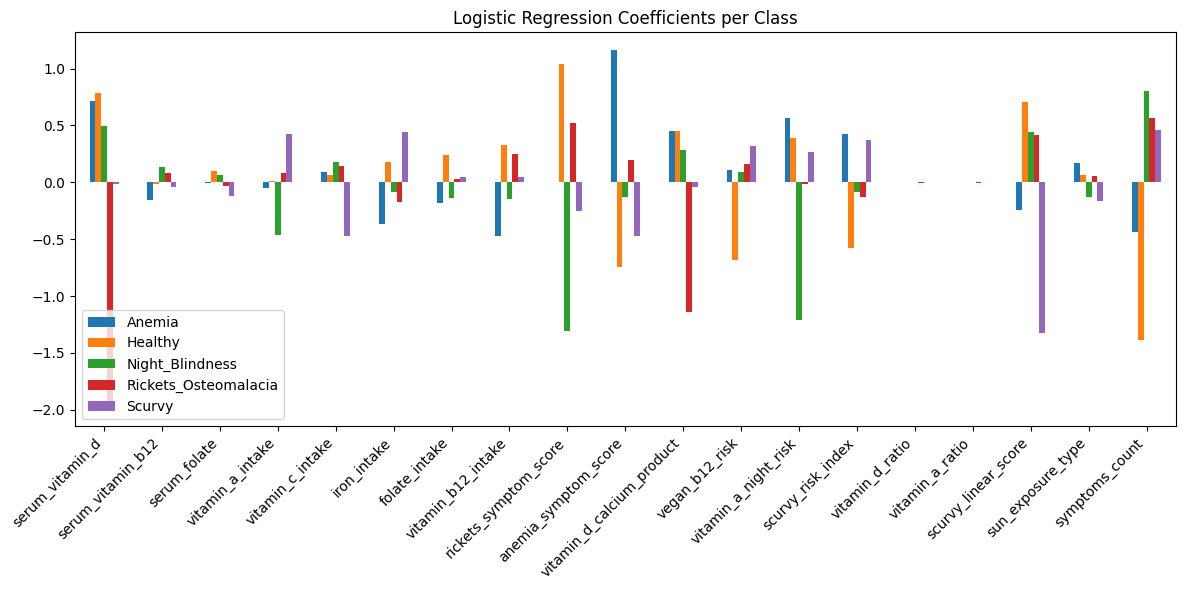

In [39]:
coef_df = pd.DataFrame(
    best_lr.coef_,
    columns=features_list,
    index=best_lr.classes_
)

fig, ax = plt.subplots(figsize=(12, 6))
coef_df.T.plot(kind='bar', ax=ax)
plt.title("Logistic Regression Coefficients per Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

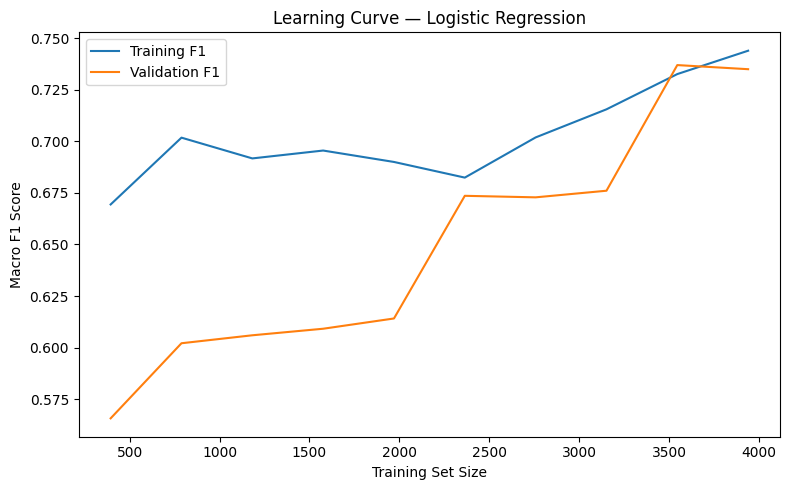

In [40]:
# Learning Curve - on resampled data
train_sizes, train_scores, val_scores = learning_curve(
    best_lr, X_train_resampled, y_train_resampled,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=3, n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

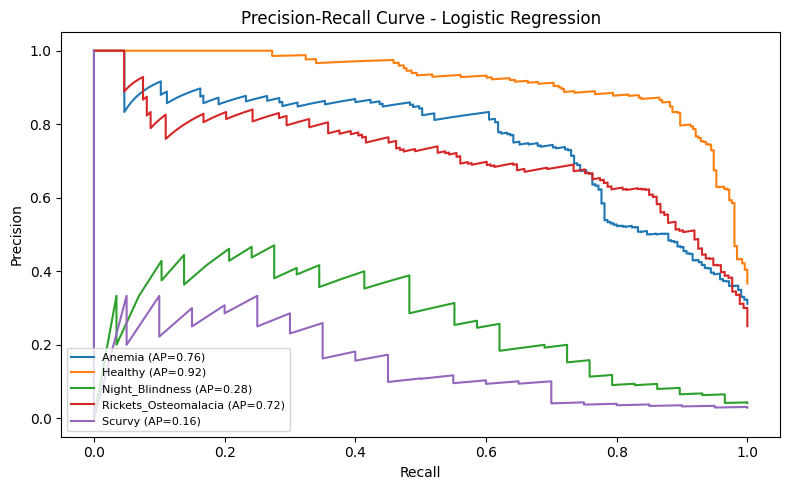

In [41]:
# Precision-Recall Curve
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_lr.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [42]:
# Per-class F1
f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)
data = pd.DataFrame({'Class': classes, 'F1 Score': f1_scores.round(3)})
chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(width=400, height=300, title='Per-class F1 Score — Logistic Regression')
chart

alt.Chart(...)

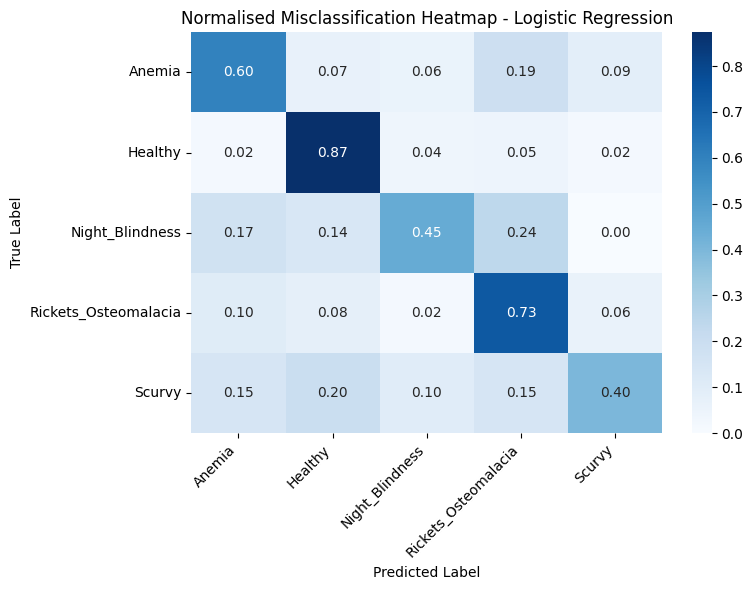

In [43]:
# Normalised Misclassification Heatmap
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Normalised Misclassification Heatmap - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = [0.793, 0.865, 0.500, 0.734, 0.513]
rf_f1 = [0.823, 0.878, 0.667, 0.781, 0.516]
hgb_f1 = [0.840, 0.910, 0.700, 0.810, 0.560]
xgb_f1 = [0.864, 0.930, 0.643, 0.810, 0.571]
lr_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 6,
    'Model': ['Dummy']*5 + ['Decision Tree']*5 + ['Random Forest']*5 +
             ['HistGradientBoosting']*5 + ['XGBoost']*5 + ['Logistic Regression']*5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1, *rf_f1, *hgb_f1, *xgb_f1, *lr_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree', 'Random Forest',
                'HistGradientBoosting', 'XGBoost', 'Logistic Regression'],
        range=['#95a5a6', '#e67e22', '#8e44ad', '#27ae60', '#2980b9', '#c0392b']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=100,
    height=300,
    title='F1 Score Comparison: All Models'
)

print(f"Dummy Macro F1:                0.1073")
print(f"Decision Tree Macro F1:        0.6809")
print(f"Random Forest Macro F1:        0.7329")
print(f"HistGradientBoosting Macro F1: 0.7647")
print(f"XGBoost Macro F1:              0.7638")
print(f"Logistic Regression Macro F1:  {macro_f1_val:.4f}")

chart

Dummy Macro F1:                0.1073
Decision Tree Macro F1:        0.6809
Random Forest Macro F1:        0.7329
HistGradientBoosting Macro F1: 0.7647
XGBoost Macro F1:              0.7638
Logistic Regression Macro F1:  0.5770


alt.Chart(...)

In [45]:
model_performance_explanations = """
Logistic Regression achieves a macro F1 of 0.5770 on the validation
set, the weakest result across all five experiments and substantially
below the tree based approaches. This confirms that the disease
classification problem is not linearly separable in its current feature
space. The relationships between vitamin deficiencies, symptoms and
disease classes are complex and non-linear in ways that a linear
decision boundary cannot adequately capture regardless of how the
features are engineered or scaled.

The learning curve tells a fundamentally different story from all
previous experiments. Training F1 starts at 0.67 and only reaches
0.74 at full training size, meaning the model never memorises the
training data. More importantly the training and validation curves
converge toward each other at larger training sizes with both sitting
around 0.735 at the rightmost point. This is the only experiment
where the two curves converge rather than diverge, indicating
Logistic Regression is not overfitting. The problem is not variance
but bias. The model lacks the capacity to fit the underlying patterns
regardless of how much data it receives.

Per class F1 scores reflect this clearly. Healthy holds at 0.87
because it is the most linearly separable class with consistently
high vitamin levels and zero symptoms. Rickets reaches 0.70 and
Anemia 0.69. Night_Blindness drops sharply to 0.38 and Scurvy
collapses to 0.25, the worst minority class results across all
experiments. The linear model cannot find clean boundaries for
classes that overlap heavily in feature space with other diseases.

The precision recall curves confirm the breakdown on minority
classes. Night_Blindness AP dropped from 0.71 in HistGradientBoosting
to 0.28 and Scurvy from 0.54 to 0.16. These are catastrophic drops
that reflect the fundamental limitation of linear boundaries for
these classes. Anemia dropped from AP=0.94 to AP=0.76 and Rickets
from AP=0.89 to AP=0.72. Only Healthy remained relatively strong
at AP=0.92.

The normalised misclassification heatmap shows Anemia at only 60
percent correct with 19 percent predicted as Rickets and 9 percent
as Scurvy. Night_Blindness at 45 percent correct is scattered across
all classes. Scurvy at 40 percent correct matches the Random Forest
result but with precision of only 0.19 meaning most Scurvy
predictions are wrong. The coefficient plot shows the model is using
anemia_symptom_score and symptoms_count as its strongest signals
but the linear combinations of these features cannot replicate the
complex interaction patterns that gradient boosting captures through
hundreds of sequential trees.

The F1 comparison across all six models confirms that tree based
approaches consistently and substantially outperform linear models
for this dataset. HistGradientBoosting remains the best performing
model at macro F1 of 0.7647, followed closely by XGBoost at 0.7638
and Random Forest at 0.7329. Logistic Regression at 0.5770 sits
only marginally above the Decision Tree at 0.6809 and well below
all ensemble methods. For a clinical screening tool where minority
class recall is critical the recommendation is to proceed with
HistGradientBoosting as the final model.
"""

In [46]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [47]:
business_impacts_explanations = """
Logistic Regression with SMOTE is the weakest model across all experiments
from a clinical standpoint, despite SMOTE being designed to address the
minority class problem.

The core issue is precision. A Scurvy precision of 0.19 means that for every
5 patients flagged as Scurvy, only 1 actually has it. In a clinical setting
this would send 4 healthy or Anemia patients through unnecessary Scurvy
treatment pathways for every correct diagnosis. This level of false positives
would erode clinician trust in the tool immediately.

Night_Blindness has the same problem at 0.33 precision. Two out of every
three Night_Blindness predictions are wrong — patients are being incorrectly
redirected to vitamin A interventions when they actually have other conditions.

Anemia recall dropping to 0.60 is also concerning. Previous experiments
consistently caught 80%+ of Anemia cases. this model misses 40%, which
is a significant step backward for the most common disease class after Healthy.

Healthy remains well handled at 0.87 F1, which is the one positive result.
The model is not over-diagnosing healthy patients as sick at an alarming rate.

The lesson from this experiment is that SMOTE alone is not sufficient — the
quality of synthetic samples matters as much as the quantity. When minority
class samples overlap heavily with other classes in feature space, SMOTE
generates synthetic samples in ambiguous regions that confuse the model
rather than helping it. A non-linear model like SVM in Experiment 6 may
handle these overlapping boundaries better.
"""

In [48]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [49]:
experiment_outcome = "Hypothesis Not Confirmed"

In [50]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [51]:
experiment_results_explanations = """
The hypothesis is not confirmed. Logistic Regression with SMOTE achieved a
macro F1 of 0.5770 well below the 0.78 target and significantly worse than
all tree-based experiments. The experiment confirmed that the 5 vitamin
deficiency classes are not linearly separable in the current feature space.

The most important finding is the massive cross-val to validation gap of 0.158.
SMOTE inflates cross-val scores because synthetic samples are evaluated in the
same folds they were generated from, giving an unrealistically optimistic view
of performance. This is a critical lesson  when using SMOTE, cross-val scores
must be interpreted with caution.

The second key insight is that SMOTE with a linear model in overlapping feature
space generates noisy synthetic samples. Scurvy and Anemia share similar feature
profiles low intake, fatigue, pale skin  so SMOTE-generated Scurvy samples
land in Anemia territory and vice versa. The result is high recall but collapsed
precision, which is clinically worse than low recall with high precision.

Tree-based models handle these overlapping boundaries through non-linear splits
which Logistic Regression fundamentally cannot do.

Next steps:

1. SVM with RBF kernel (Experiment 6), kernel methods can find non-linear
   boundaries in high dimensional space. An RBF kernel maps the features into
   a higher dimensional space where the classes may become separable. Combined
   with SMOTE this could improve on Logistic Regression significantly.

2. The best model so far remains HistGradientBoosting at macro F1 0.7647.
   If SVM does not improve on this, the recommendation will be to use
   HistGradientBoosting as the final model and address Scurvy recall through
   data collection rather than algorithmic fixes.
"""

In [52]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)